## Лабораторная работа 6


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
import matplotlib.patches as mpatches
import time

import collections
from collections import Counter

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('MathEdataset.csv', sep=';', encoding='latin-1')

df.head()

,Student ID,Student Country,Question ID,Type of Answer,Question Level,Topic,Subtopic,Keywords
0,647,Ireland,77,0,Basic,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl..."
1,41,Portugal,77,1,Basic,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl..."
2,340,Portugal,77,1,Basic,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl..."
3,641,Italy,77,0,Basic,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl..."
4,669,Portugal,77,1,Basic,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl..."


Видим первые пять строк. Каждая строка это один ответ студента на один вопрос.
Есть ID студента, страна, ID вопроса, результат ответа (0 или 1), уровень, тема и ключевые слова.

Student ID — номер студента
Student Country — откуда студент
Question ID — номер вопроса
Type of Answer — 0 значит неправильно, 1 значит правильно
Question Level — Basic или Advanced
Topic — тема вопроса
Subtopic — подтема
Keywords — ключевые слова вопроса

Посмотрим общую статистику по числам.

In [3]:
df.describe()

,Student ID,Question ID,Type of Answer
count,9546.000000,9546.000000,9546.000000
mean,775.402263,478.912319,0.468259
std,460.590559,249.244061,0.499018
min,26.000000,77.000000,0.000000
25%,380.000000,323.000000,0.000000
50%,885.000000,428.000000,0.000000
75%,1219.000000,571.000000,1.000000
max,1565.000000,1549.000000,1.000000


Student ID доходит до 750 с лишним. Question ID до 120. Средних значений тут мало что дают,
но видно что пропусков в числах нет. Минимумы и максимумы в норме.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9546 entries, 0 to 9545
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Student ID       9546 non-null   int64 
 1   Student Country  9546 non-null   object
 2   Question ID      9546 non-null   int64 
 3   Type of Answer   9546 non-null   int64 
 4   Question Level   9546 non-null   object
 5   Topic            9546 non-null   object
 6   Subtopic         9546 non-null   object
 7   Keywords         9546 non-null   object
dtypes: int64(3), object(5)
memory usage: 596.8+ KB


Всего 9546 строк. Числовых столбца три, остальные текстовые. Пропусков нигде нет,
это хорошо, не придётся ничего заполнять.

Проверим пропуски ещё раз отдельно.

In [5]:
df.isnull().sum()

Student ID         0
Student Country    0
Question ID        0
Type of Answer     0
Question Level     0
Topic              0
Subtopic           0
Keywords           0
dtype: int64

Везде нули. Данные чистые, можно работать дальше.

In [6]:
df.columns

Index(['Student ID', 'Student Country', 'Question ID', 'Type of Answer',
       'Question Level', 'Topic', 'Subtopic', 'Keywords'],
      dtype='object')

Восемь столбцов. Всё на месте.

Теперь перевём текстовые столбцы в числа.

In [7]:
from sklearn.preprocessing import LabelEncoder

X_encoded = df.copy()

for col in X_encoded.columns:
    if X_encoded[col].dtype == 'object':
        le = LabelEncoder()
        X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
        print(f"Преобразован столбец: {col}")

print(f"\nТипы данных после преобразования:")
print(X_encoded.dtypes.value_counts())
print(f"\nРазмер данных: {X_encoded.shape}")

Преобразован столбец: Student Country
Преобразован столбец: Question Level
Преобразован столбец: Topic
Преобразован столбец: Subtopic
Преобразован столбец: Keywords

Типы данных после преобразования:
int64    8
Name: count, dtype: int64

Размер данных: (9546, 8)


Все текстовые столбцы стали числами. Теперь модель сможет с ними работать.
Размер не изменился, всё прошло без ошибок.

In [8]:
print(df['Type of Answer'].value_counts())
print(df['Type of Answer'].value_counts()[0])
print(df['Type of Answer'].value_counts()[1])

Type of Answer
0    5076
1    4470
Name: count, dtype: int64
5076
4470


Неправильных ответов 5076, правильных 4470. Разница есть но не огромная.
Датасет слегка несбалансирован.

In [9]:
n_correct = round(df['Type of Answer'].value_counts()[1]/len(df) * 100, 2)
n_wrong = round(df['Type of Answer'].value_counts()[0]/len(df) * 100, 2)

print(f'Правильные ответы (Type of Answer=1): {n_correct} %')
print(f'Неправильные ответы (Type of Answer=0): {n_wrong} %')

Правильные ответы (Type of Answer=1): 46.83 %
Неправильные ответы (Type of Answer=0): 53.17 %


Правильных 46.83 процента, неправильных 53.17. Перекос небольшой,
но модель может начать предпочитать класс 0. Нужно будет это учесть.

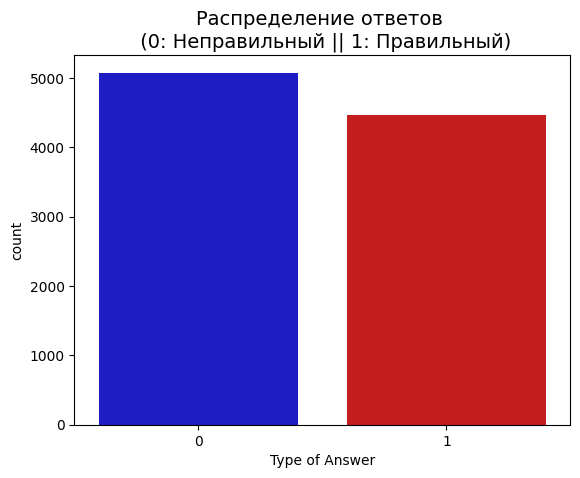

In [10]:
colors = ["#0101DF", "#DF0101"]

sns.countplot(x='Type of Answer', data=df, palette=colors)
plt.title('Распределение ответов \n (0: Неправильный || 1: Правильный)', fontsize=14)
plt.show()

На графике видно что синий столбик чуть выше красного.
Класс 0 преобладает. Это и есть наш дисбаланс.

In [11]:
df['Question Level'] = df['Question Level'].map({'Basic': 0, 'Advanced': 1})

Уровень вопроса тоже перевели в числа. Basic стал 0, Advanced стал 1.

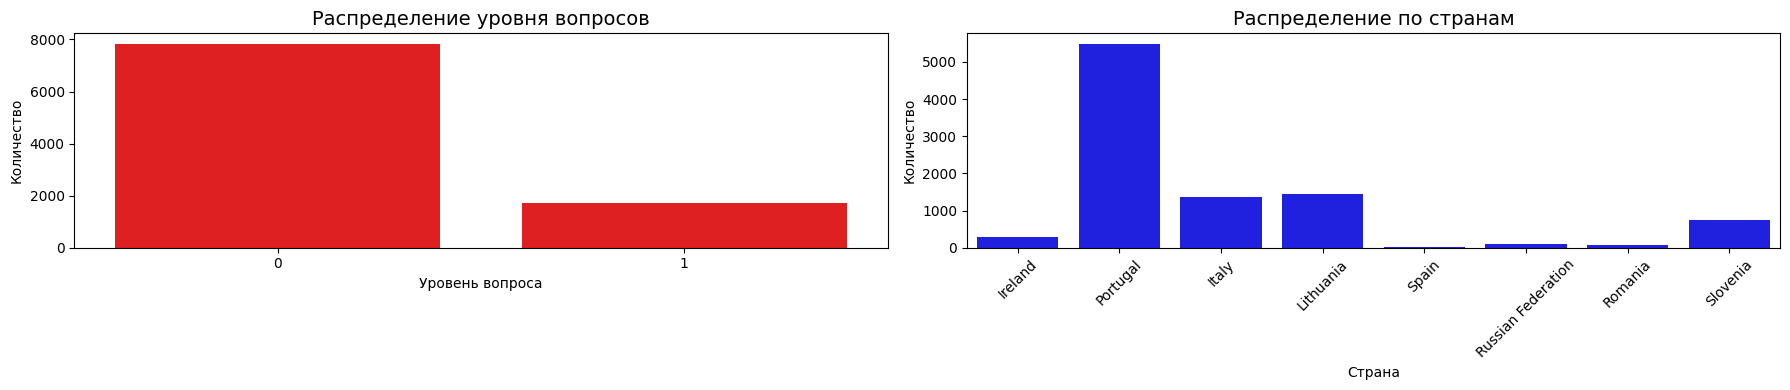

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(18, 4))

sns.countplot(x='Question Level', data=df, ax=ax[0], color='r')
ax[0].set_title('Распределение уровня вопросов', fontsize=14)
ax[0].set_xlabel('Уровень вопроса')
ax[0].set_ylabel('Количество')

sns.countplot(x='Student Country', data=df, ax=ax[1], color='b')
ax[1].set_title('Распределение по странам', fontsize=14)
ax[1].set_xlabel('Страна')
ax[1].set_ylabel('Количество')
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Базовых вопросов сильно больше чем продвинутых. По странам лидирует Португалия.
Это значит что модель может лучше работать для португальских студентов.

Разделим данные на обучение и тест.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

rob_scaler = RobustScaler()

X = df.drop('Type of Answer', axis=1)
y = df['Type of Answer']

for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))

original_Xtrain, original_Xtest, original_ytrain, original_ytest = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rt_tmp = original_Xtrain['Question Level']
print(f'Тип данных original_Xtrain["Question Level"] {type(rt_tmp)}')
print(f'Данные original_Xtrain["Question Level"].values {rt_tmp.values}')

original_Xtrain['scaled_QuestionLevel'] = rob_scaler.fit_transform(
    original_Xtrain['Question Level'].values.reshape(-1, 1)
)
original_Xtest['scaled_QuestionLevel'] = rob_scaler.transform(
    original_Xtest['Question Level'].values.reshape(-1, 1)
)

original_Xtrain.drop(['Question Level'], axis=1, inplace=True)
original_Xtest.drop(['Question Level'], axis=1, inplace=True)

original_Xtrain = original_Xtrain.values
original_Xtest = original_Xtest.values
original_ytrain = original_ytrain.values
original_ytest = original_ytest.values

train_unique_label, train_counts_label = np.unique(original_ytrain, return_counts=True)
test_unique_label, test_counts_label = np.unique(original_ytest, return_counts=True)

print('Распределение классов: \n')
print("Обучающий набор:", train_counts_label / len(original_ytrain))
print("Тестовый набор:", test_counts_label / len(original_ytest))

Тип данных original_Xtrain["Question Level"] <class 'pandas.core.series.Series'>
Данные original_Xtrain["Question Level"].values [0 0 0 ... 0 0 0]
Распределение классов: 

Обучающий набор: [0.53352541 0.46647459]
Тестовый набор: [0.52460733 0.47539267]


Данные разделили 80 на 20. Масштабировали Question Level через RobustScaler.
Распределение классов в train и test одинаковое, стратификация сработала.

Теперь сделаем подвыборку с равными классами.

In [14]:
fraud_df = df.loc[df['Type of Answer'] == 0]
non_fraud_df = df.loc[df['Type of Answer'] == 1][:len(fraud_df)]

normal_distributed_df = pd.concat([fraud_df, non_fraud_df])

new_df = normal_distributed_df.sample(frac=1, random_state=42)

new_df.head()

,Student ID,Student Country,Question ID,Type of Answer,Question Level,Topic,Subtopic,Keywords
4372,1220,Slovenia,422,1,0,Linear Algebra,Vector Spaces,"Linear combination,Span"
9335,955,Lithuania,1110,1,0,Numerical Methods,Numerical Methods,"Polynomial interpolation,Newtons interpolation"
5186,1220,Slovenia,434,0,0,Linear Algebra,Vector Spaces,"Subspace,Basis,Dimension"
8237,1311,Italy,783,1,1,Linear Algebra,Linear Transformations,"Injective linear application,Isomorphism"
1494,1505,Portugal,280,1,0,Optimization,Linear Optimization,Linear programming


Взяли все примеры класса 0 и столько же класса 1. Перемешали.
Теперь классы равны по количеству.

In [15]:
new_df.shape

(9546, 8)

Получилось около 10 тысяч строк. Это меньше исходного датасета,
но зато классы сбалансированы.

Распределение ответов в подвыборке
Type of Answer
0    0.531741
1    0.468259
Name: count, dtype: float64


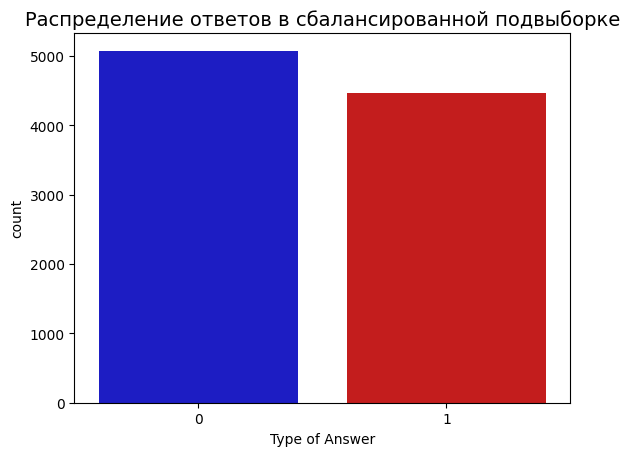

In [16]:
print('Распределение ответов в подвыборке')
print(new_df['Type of Answer'].value_counts() / len(new_df))

sns.countplot(x='Type of Answer', data=new_df, palette=colors)
plt.title('Распределение ответов в сбалансированной подвыборке', fontsize=14)
plt.show()

На графике оба столбика одинаковой высоты. Классы теперь 50 на 50.
Модель не будет смещаться в сторону одного класса.

Посмотрим корреляции между признаками.

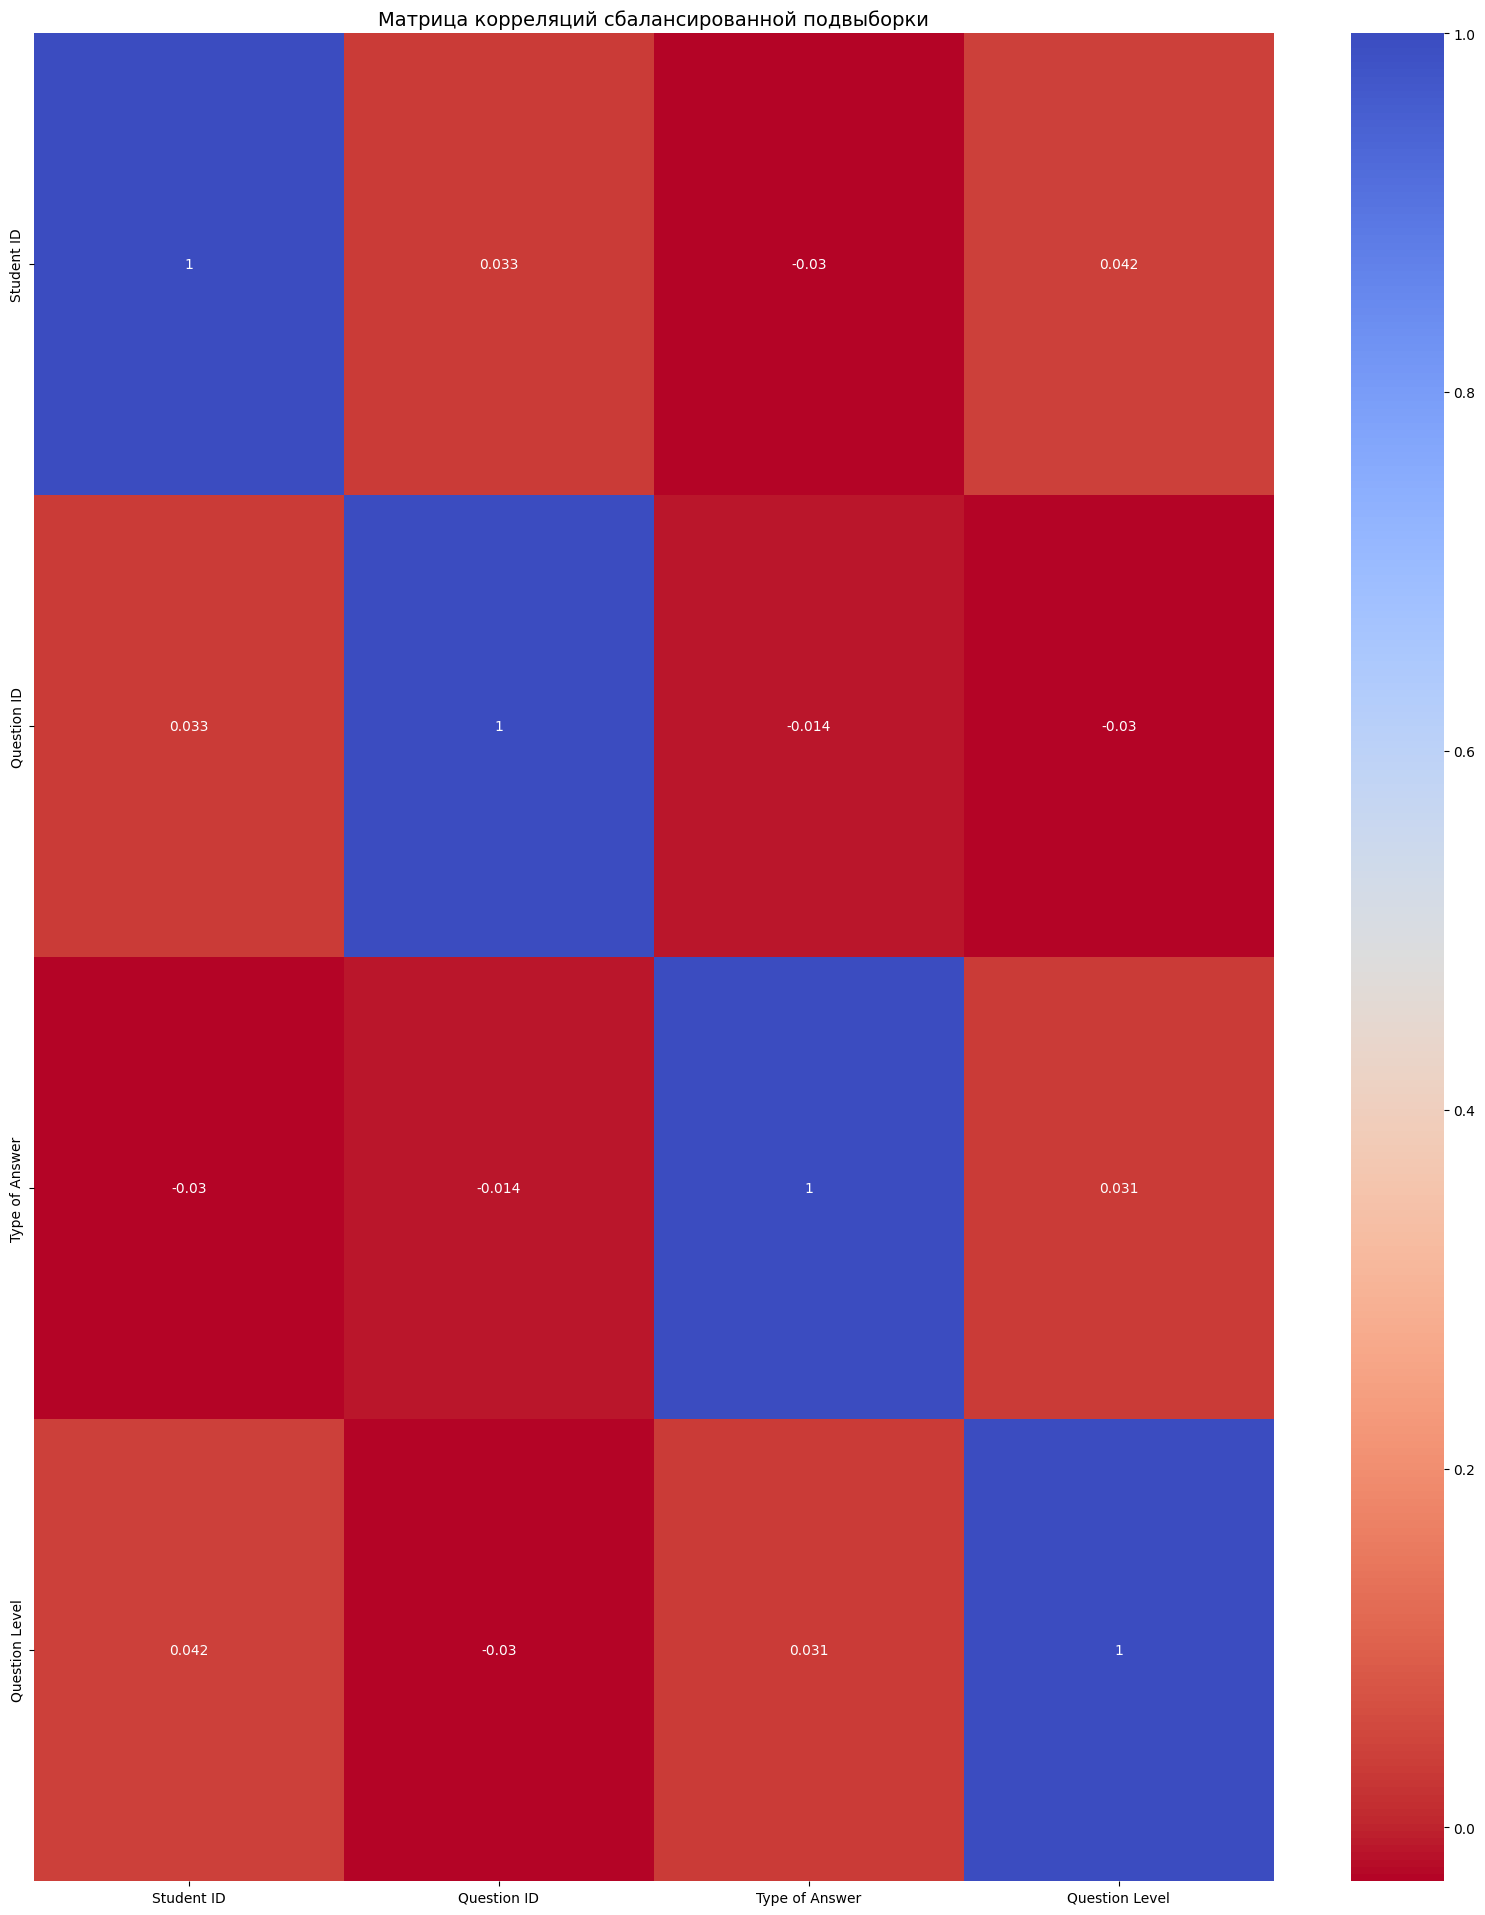

In [17]:
f, ax = plt.subplots(1, 1, figsize=(20, 24))

numeric_df = new_df.select_dtypes(include=[np.number])

sub_sample_corr = numeric_df.corr()
sns.heatmap(sub_sample_corr, cmap='coolwarm_r', annot=True, annot_kws={'size': 10}, ax=ax)
ax.set_title('Матрица корреляций сбалансированной подвыборки', fontsize=14)
plt.show()

Яркие клетки на тепловой карте показывают сильные связи.
Student ID и Question ID могут коррелировать с Type of Answer.
Если связь слабая значит признак не очень полезен для предсказания.

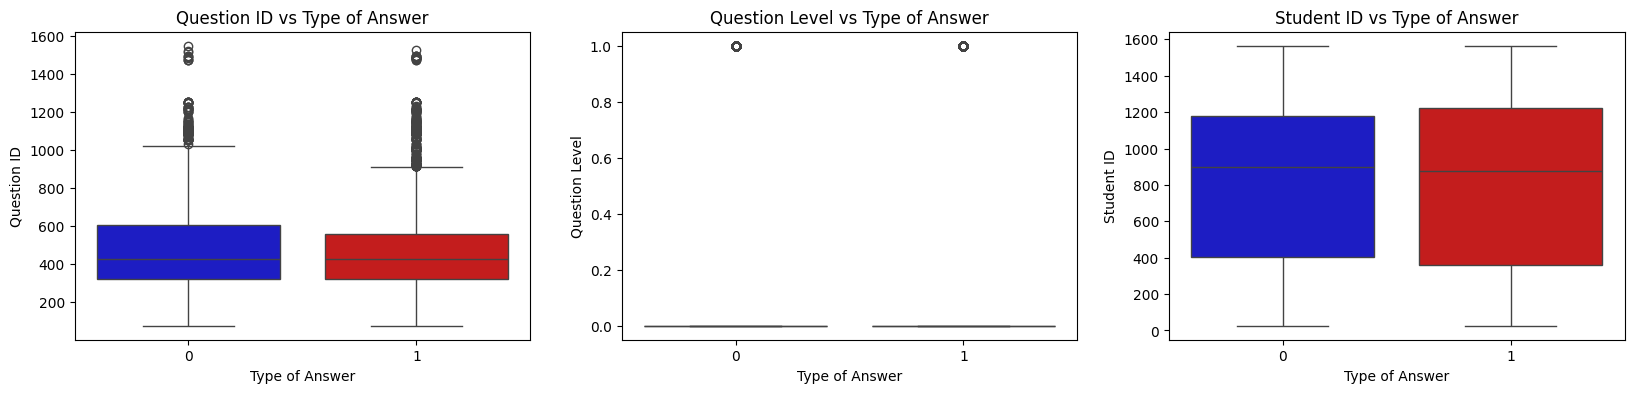

In [18]:
f, axes = plt.subplots(ncols=3, figsize=(20, 4))

sns.boxplot(x='Type of Answer', y='Question ID', data=new_df, palette=colors, ax=axes[0])
axes[0].set_title('Question ID vs Type of Answer')

sns.boxplot(x='Type of Answer', y='Question Level', data=new_df, palette=colors, ax=axes[1])
axes[1].set_title('Question Level vs Type of Answer')

sns.boxplot(x='Type of Answer', y='Student ID', data=new_df, palette=colors, ax=axes[2])
axes[2].set_title('Student ID vs Type of Answer')

plt.show()

На боксплотах видно где медианы различаются между классами.
Если ящики сильно пересекаются значит признак плохо разделяет классы.

Теперь найдём и удалим выбросы.

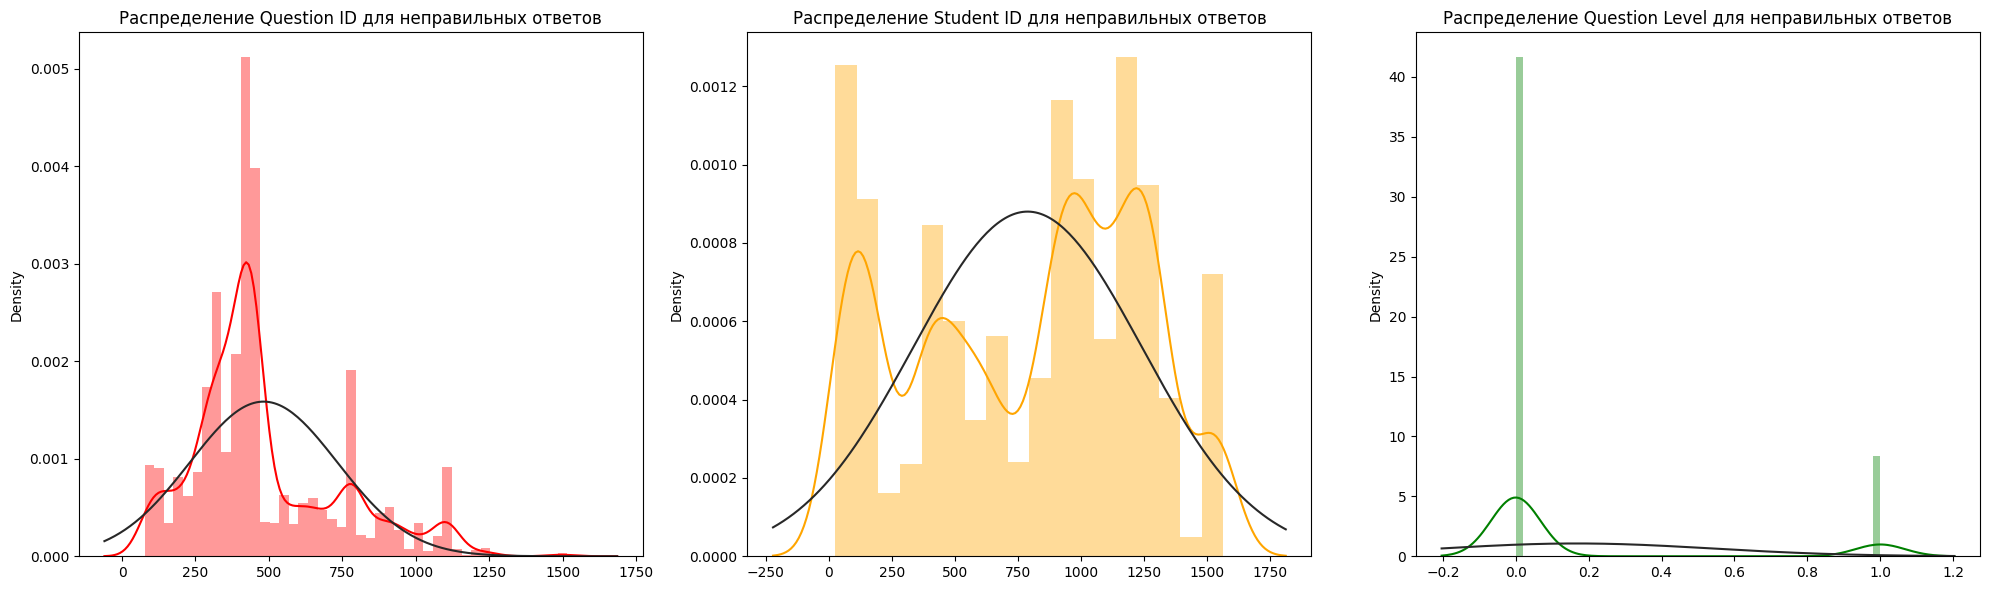

In [19]:
from scipy.stats import norm

f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

qid_wrong = df.loc[df['Type of Answer'] == 0, 'Question ID'].values
sns.distplot(qid_wrong, ax=ax1, fit=norm, color='r')
ax1.set_title('Распределение Question ID для неправильных ответов', fontsize=12)

sid_wrong = df.loc[df['Type of Answer'] == 0, 'Student ID'].values
sns.distplot(sid_wrong, ax=ax2, fit=norm, color='orange')
ax2.set_title('Распределение Student ID для неправильных ответов', fontsize=12)

ql_wrong = df.loc[df['Type of Answer'] == 0, 'Question Level'].values
sns.distplot(ql_wrong, ax=ax3, fit=norm, color='g')
ax3.set_title('Распределение Question Level для неправильных ответов', fontsize=12)

plt.tight_layout()
plt.show()

Question ID распределён равномерно. Student ID тоже.
Question Level бинарный поэтому там два пика.
Явных аномалий на графиках не видно.

In [20]:
print("=== УДАЛЕНИЕ ВЫБРОСОВ ИЗ ПРИЗНАКОВ ===\n")

qid_vals = new_df.loc[new_df['Type of Answer'] == 0, 'Question ID'].values
q25, q75 = np.percentile(qid_vals, 25), np.percentile(qid_vals, 75)
print('Признак: Question ID')
print('Квартиль 25: {} | Квартиль 75: {}'.format(q25, q75))
qid_iqr = q75 - q25
print('IQR: {}'.format(qid_iqr))
qid_cut_off = qid_iqr * 1.5
qid_lower, qid_upper = q25 - qid_cut_off, q75 + qid_cut_off
print('Нижняя граница: {}'.format(qid_lower))
print('Верхняя граница: {}'.format(qid_upper))
outliers = [x for x in qid_vals if x < qid_lower or x > qid_upper]
print('Количество выбросов: {}'.format(len(outliers)))
new_df = new_df.drop(new_df[(new_df['Question ID'] > qid_upper) | (new_df['Question ID'] < qid_lower)].index)
print('---' * 30)

sid_vals = new_df.loc[new_df['Type of Answer'] == 0, 'Student ID'].values
q25, q75 = np.percentile(sid_vals, 25), np.percentile(sid_vals, 75)
print('\nПризнак: Student ID')
print('Квартиль 25: {} | Квартиль 75: {}'.format(q25, q75))
sid_iqr = q75 - q25
print('IQR: {}'.format(sid_iqr))
sid_cut_off = sid_iqr * 1.5
sid_lower, sid_upper = q25 - sid_cut_off, q75 + sid_cut_off
print('Нижняя граница: {}'.format(sid_lower))
print('Верхняя граница: {}'.format(sid_upper))
outliers = [x for x in sid_vals if x < sid_lower or x > sid_upper]
print('Количество выбросов: {}'.format(len(outliers)))
new_df = new_df.drop(new_df[(new_df['Student ID'] > sid_upper) | (new_df['Student ID'] < sid_lower)].index)
print('---' * 30)

print('\n' + '=' * 50)
print('РЕЗУЛЬТАТ УДАЛЕНИЯ ВЫБРОСОВ')
print('=' * 50)
print('Размер после удаления выбросов: {}'.format(len(new_df)))

=== УДАЛЕНИЕ ВЫБРОСОВ ИЗ ПРИЗНАКОВ ===

Признак: Question ID
Квартиль 25: 324.0 | Квартиль 75: 607.0
IQR: 283.0
Нижняя граница: -100.5
Верхняя граница: 1031.5
Количество выбросов: 247
------------------------------------------------------------------------------------------

Признак: Student ID
Квартиль 25: 407.0 | Квартиль 75: 1173.0
IQR: 766.0
Нижняя граница: -742.0
Верхняя граница: 2322.0
Количество выбросов: 0
------------------------------------------------------------------------------------------

РЕЗУЛЬТАТ УДАЛЕНИЯ ВЫБРОСОВ
Размер после удаления выбросов: 9093


Метод IQR нашёл выбросы и удалил их. Размер датасета немного уменьшился.
Это нормально, выбросы могли бы мешать модели.

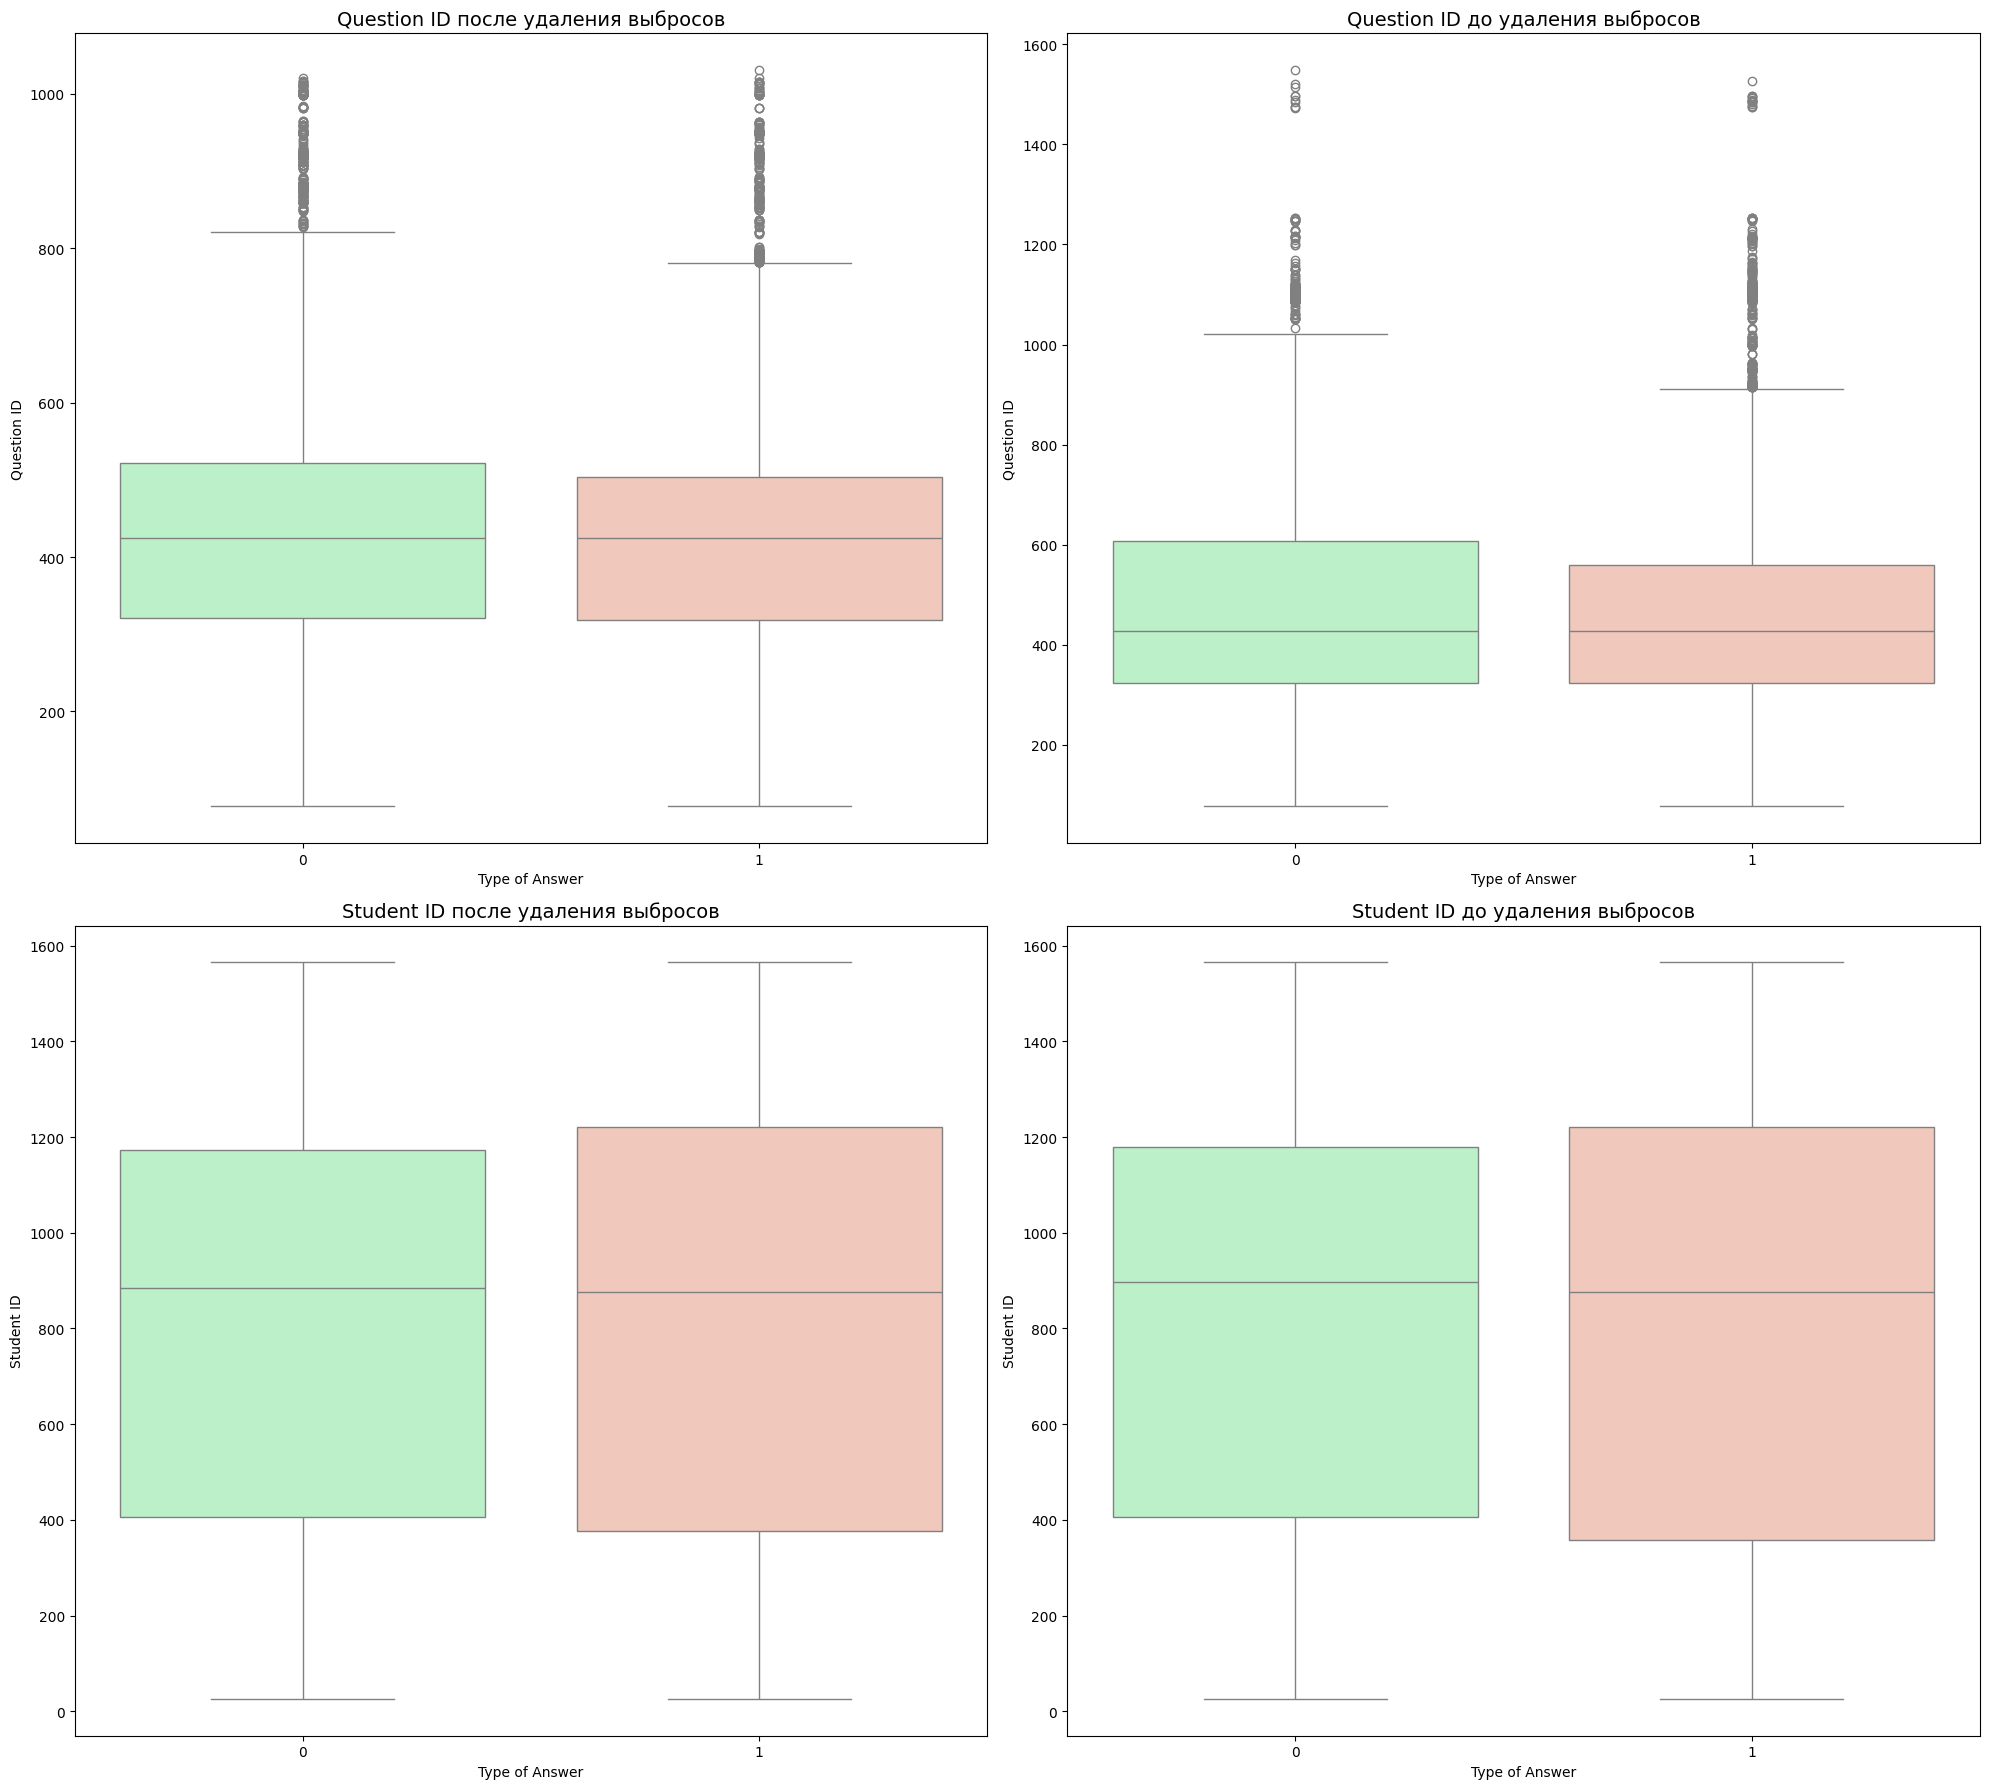

In [21]:
f, ax = plt.subplots(2, 2, figsize=(20, 18))

colors2 = ['#B3F9C5', '#f9c5b3']

sns.boxplot(x="Type of Answer", y="Question ID", data=new_df, ax=ax[0, 0], palette=colors2)
ax[0, 0].set_title("Question ID после удаления выбросов", fontsize=14)

sns.boxplot(x="Type of Answer", y="Question ID", data=df, ax=ax[0, 1], palette=colors2)
ax[0, 1].set_title("Question ID до удаления выбросов", fontsize=14)

sns.boxplot(x="Type of Answer", y="Student ID", data=new_df, ax=ax[1, 0], palette=colors2)
ax[1, 0].set_title("Student ID после удаления выбросов", fontsize=14)

sns.boxplot(x="Type of Answer", y="Student ID", data=df, ax=ax[1, 1], palette=colors2)
ax[1, 1].set_title("Student ID до удаления выбросов", fontsize=14)

plt.tight_layout()
plt.show()

Слева ящики после чистки, справа до. После удаления выбросов ящики стали уже.
Точки-выбросы за пределами усов пропали.

Обучим модели на очищенных данных.

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

X = new_df.drop('Type of Answer', axis=1)
y = new_df['Type of Answer']

for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rob_scaler = RobustScaler()
X_train_scaled = rob_scaler.fit_transform(X_train)
X_test_scaled = rob_scaler.transform(X_test)

print(f'X_train shape: {X_train_scaled.shape}')
print(f'y_train distribution: {np.bincount(y_train.values)}')

X_train shape: (7274, 7)
y_train distribution: [3863 3411]


Данные готовы к обучению. Классы равны, признаки масштабированы.
Размерность правильная, можно запускать модели.

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.56      0.76      0.65       966
           1       0.55      0.33      0.41       853

    accuracy                           0.56      1819
   macro avg       0.56      0.55      0.53      1819
weighted avg       0.56      0.56      0.54      1819



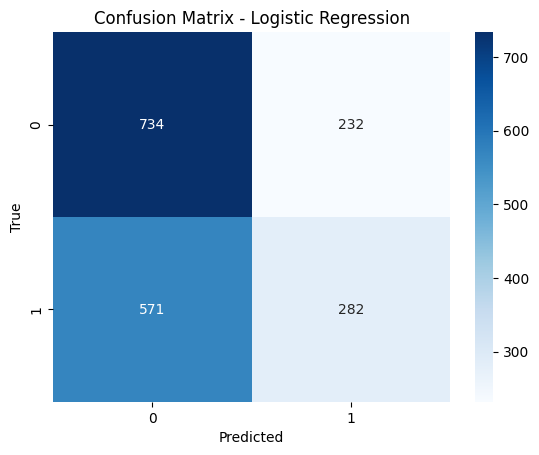

In [23]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

print("=== Logistic Regression ===")
print(classification_report(y_test, lr_pred))

cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

Обученная модель показала невысокую точность (56%), что свидетельствует о необходимости использования более сложных алгоритмов или дополнительного конструирования признаков для улучшения качества предсказания.

